# Aufgabe 2

In [82]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data

image = plt.imread("schraegbild_tempelhof.jpg")
image = image.astype(float)
image = image / 255

# Test

In [83]:
# Ausgangskoordinaten
bi = np.array([
    [347, 326],
    [531, 324],
    [268, 547],
    [841, 524]
])
# Zielkoordinaten
oi = np.array([
    [0, 0],
    [400, 0],
    [0, 600],
    [400, 600]
])

In [84]:
def compute_rectification(oi, bi):
    A = []
    for i in range(4):
        x, y = bi[i]
        u, v = oi[i]
        A.append([x, y, 1, 0, 0, 0, -(u*x), -(u*y)])
        A.append([0, 0, 0, x, y, 1, -(v*x), -(v*y)])
    A = np.array(A)
    #U, S, Vt = np.linalg.svd(A)
    #H = Vt[-1].reshape(3, 3)
    return  A
A = compute_rectification(oi, bi)
A_inverse = np.linalg.inv(A)
x = oi
a_small = A_inverse @ x.flatten()
transformed_points = []
for i in range(4):
    x = (a_small[0] * bi[i][0] + a_small[1] * bi[i][1] + a_small[2]) / (a_small[6] * bi[i][0] + a_small[7] * bi[i][1] + 1)
    y = (a_small[3] * bi[i][0] + a_small[4] * bi[i][1] + a_small[5]) / (a_small[6] * bi[i][0] + a_small[7] * bi[i][1] + 1)
    transformed_points.append([x, y])
print("transformed points:\n", transformed_points)
print("A Matrix:\n", A)


transformed points:
 [[-3.943641023792122e-13, 5.258188031722829e-13], [399.99999999999966, 5.391489340076538e-13], [-1.2122816652452244e-13, 599.9999999999997], [399.99999999999983, 600.0000000000001]]
A Matrix:
 [[    347     326       1       0       0       0       0       0]
 [      0       0       0     347     326       1       0       0]
 [    531     324       1       0       0       0 -212400 -129600]
 [      0       0       0     531     324       1       0       0]
 [    268     547       1       0       0       0       0       0]
 [      0       0       0     268     547       1 -160800 -328200]
 [    841     524       1       0       0       0 -336400 -209600]
 [      0       0       0     841     524       1 -504600 -314400]]


In [85]:
def apply_homography(H, points):
    num_points = points.shape[0]
    homogeneous_points = np.hstack((points, np.ones((num_points, 1))))
    transformed_points = homogeneous_points @ H.T
    transformed_points /= transformed_points[:, 2][:, np.newaxis]
    return transformed_points

transformed_bi = apply_homography(H, bi)
print("Transformed Points:\n", transformed_bi)
print("Original Points:\n", oi)

Transformed Points:
 [[-3.42597725e-13  2.10115185e-09  1.00000000e+00]
 [ 4.00000000e+02 -3.51282984e-13  1.00000000e+00]
 [-5.97031290e-10  6.00000000e+02  1.00000000e+00]
 [ 4.00000000e+02  6.00000000e+02  1.00000000e+00]]
Original Points:
 [[  0   0]
 [400   0]
 [  0 600]
 [400 600]]


In [ ]:
H_inverse = []
a1 = a_small[0]
a2 = a_small[1]
a3 = a_small[2]
b1 = a_small[3]
b2 = a_small[4]
b3 = a_small[5]
c1 = a_small[6]
c2 = a_small[7]
for i in range(4):
    x_ref = oi[i][0]
    y_ref = oi[i][1]
    x = ((b2 - c2*b3)*x_ref + (a3*c2- a2)*y_ref + a2*b3 - a3*b2) / ((b1*c2 - b2*c1)*x_ref + (a2*c1 - a1*c2)*y_ref + a1*b2 - a2*b1)
    y = ((b3*c1 - b1)*x_ref + (a1 - a3*c1)*y_ref + a3*b1 - a1*b3) / ((b1*c2 - b2*c1)*x_ref + (a2*c1 - a1*c2)*y_ref + a1*b2 - a2*b1)
    H_inverse.append([x, y, 1])

def image_rectification(image):
    h, w = image.shape[:2]
    rectified_image = np.zeros_like(image)

    for i in range(h):
        for j in range(w):
            x_ref = i
            y_ref = j
            x = ((b2 - c2*b3)*x_ref + (a3*c2- a2)*y_ref + a2*b3 - a3*b2) / ((b1*c2 - b2*c1)*x_ref + (a2*c1 - a1*c2)*y_ref + a1*b2 - a2*b1)
            y = ((b3*c1 - b1)*x_ref + (a1 - a3*c1)*y_ref + a3*b1 - a1*b3) / ((b1*c2 - b2*c1)*x_ref + (a2*c1 - a1*c2)*y_ref + a1*b2 - a2*b1)
            x_n = int(np.round(x))
            y_n = int(np.round(y))
            if 0 <= x_n < w and 0 <= y_n < h:
                rectified_image[j, i] = image[y_n, x_n]
    return rectified_image

In [87]:
print(a_small)

[-9.20373992e-01 -3.29002468e-01  4.26624580e+02 -4.16734827e-02
 -3.83396041e+00  1.26433179e+03  1.02264559e-05 -4.40480640e-03]


(-0.5, 999.5, 756.5, -0.5)

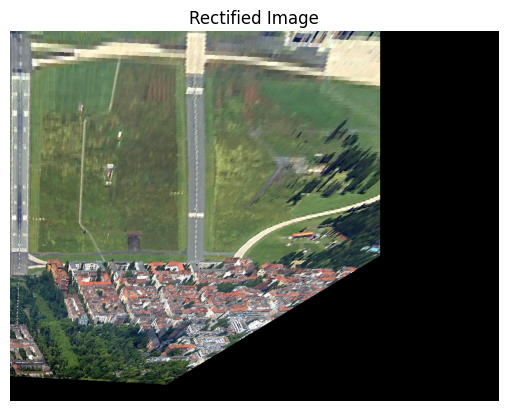

In [88]:
output_image = image_rectification(image)
plt.imshow(output_image)
plt.title("Rectified Image")
plt.axis('off')